# PharmFoldMDK in miniature — folding **NECTIN4**, live

*A hands-on tour of the whole project, on one real cancer target, start to finish.*

This notebook is the short version of what PharmFoldMDK does. Instead of running the
full system on 82 targets, it runs the **same real code** on **one** target — a protein
called **NECTIN4** — and shows you every step, live, in front of you.

**The one promise this notebook keeps:**

> *Every structural number on this page was computed, in this session, by the same code
> that runs in production, on a structure that was folded live in front of you.*

Nothing here is a screenshot, a mock-up, or a saved answer. When we fold the protein, the
protein is really folded, here, now. When we measure it, we call the exact functions the
real project uses.

---

### What you're about to see (six steps)

1. **The question** — what problem the project is trying to answer.
2. **Fold NECTIN4, live** — turn a string of letters into a 3-D shape using a deep-learning
   model (this is the slow, exciting part).
3. **Structure + confidence** — draw the shape, coloured by how sure the model is.
4. **The six measurements** — pull six numbers out of the shape.
5. **Where NECTIN4 lands** — place it in the project's ranking of targets.
6. **The honest limits** — what this does *not* prove.

---

### How to run this notebook

This notebook needs a computer with an NVIDIA GPU (the deep-learning model runs on the
graphics card). It uses a **demo-only** set of Python packages that are deliberately kept
**separate** from the ones the deployed website uses — the website has no GPU and never
ships this heavy machine-learning stack.

```bash
# from the repo root, on a GPU box:
python -m venv .venv-notebook
.venv-notebook\Scripts\activate            # Windows  (use: source .venv-notebook/bin/activate  on Linux/Mac)
pip install torch==2.11.0+cu128 --index-url https://download.pytorch.org/whl/cu128
pip install -r requirements-notebook.txt
python -m ipykernel install --user --name pharmfold-notebook
# then open this notebook and pick the "pharmfold-notebook" kernel, or run headless:
jupyter nbconvert --to notebook --execute --inplace \
  --ExecutePreprocessor.timeout=600 notebooks/miniature_NECTIN4.ipynb
```

The `import core.features` lines below find the project code by walking up to the repo
root, so the notebook works whether you launch it from `notebooks/` or the repo root.


In [1]:
# Setup: make the REAL project code importable, and show the versions we fold with.
import sys, time, json, csv, re, statistics, urllib.request
from pathlib import Path

# Walk up from the current folder until we find the repo (the folder that has core/features.py).
REPO = Path.cwd()
while REPO != REPO.parent and not (REPO / "core" / "features.py").exists():
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
print("repo root:", REPO)

import warnings, logging
warnings.filterwarnings("ignore", category=UserWarning)   # quiet benign bitsandbytes/HF notices
logging.getLogger("torch").setLevel(logging.ERROR)        # quiet the triton/flop_counter notice

import torch, transformers
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()            # keep the committed notebook's output clean

# The real project modules — not re-implementations.
from core import features as core_features
from core import scorer as core_scorer

print("torch        :", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("transformers :", transformers.__version__)
print("feature code version (source hash):", core_features.feature_version())
print("scorer  code version (source hash):", core_scorer.scorer_version())


repo root: C:\Projects\Project-PharmFoldMDK


torch        : 2.11.0+cu128 | CUDA available: True
transformers : 5.14.1
feature code version (source hash): aea7283646c8
scorer  code version (source hash): a927dc4532b7


## Step 1 — The question

An **antibody-drug conjugate** (ADC) is a cancer medicine built like a guided missile: an
antibody finds a protein that sits on the surface of a cancer cell, and a toxic payload
rides along and kills the cell. So a big question in drug design is: **which surface
proteins are good targets to aim at?**

The usual way to guess is to look at *how much* of the protein a tumour makes (its
"expression"). PharmFoldMDK asks a different question:

> **Does looking at a protein's 3-D *shape* reorder that list?**

In other words — if we fold each target into its 3-D structure and measure the shape, do
we rank the targets differently than an expression-based list would?

One important honesty note, which the project keeps everywhere: a 2024 research paper
(**Kathad et al. 2024**) gives us a published list of ADC targets to *compare against*. We
treat that paper as a **comparator, not an oracle** — a second opinion to measure agreement
and disagreement with, **not** a source of "correct answers." Nothing below treats the
paper as ground truth.


## Step 2 — Fold NECTIN4, live 🧬

**NECTIN4** is a real, approved ADC target — the medicine *enfortumab vedotin* (Padcev)
aims at it. Its identity code in the UniProt protein database is **Q96NY8**.

A protein starts life as a long string of letters, where each letter is one amino acid.
**Folding** means predicting the 3-D shape that string curls up into. We do this with a
deep-learning model called **ESMFold** — a neural network with billions of parameters that
learned the rules of protein shape from millions of known proteins. *This model is the
deep-learning heart of the whole project.*

We don't fold the whole protein. We fold just the part that sticks **outside** the cell
(the "extracellular domain", or ECD) — that's the part an antibody can actually reach. The
exact stretch to fold is read from the project's own measured data file, so we never
hard-code it here.

The next cell just prints what we're about to do. The one after it does the real folding —
**it is the slow cell**, and a slow cell here means it is *working*, not stuck.


In [2]:
# Read WHICH piece of NECTIN4 to fold from the project's measured data — nothing typed by hand.
from core.contracts import TIER_RECIPE          # the per-tier fold recipe (D-047: resolved at fold time)
from core.manifest import CEILING_KNOWN_GOOD    # the largest size known to fold cleanly on the local GPU

ACCESSION = "Q96NY8"                             # NECTIN4's UniProt id

with open(REPO / "data" / "cohort_82_ecd.csv", encoding="utf-8") as fh:
    cohort_row = next(r for r in csv.DictReader(fh) if r["accession"] == ACCESSION)

GENE          = cohort_row["gene"]
span_len      = int(cohort_row["largest_span_aa"])          # length of the ECD span, in amino acids
m             = re.search(r"(\d+)-(\d+)\((\d+)\)", cohort_row["spans"])
ecd_start, ecd_end = int(m.group(1)), int(m.group(2))       # the 1-based start/end of that span
boundary_method = "sliced_ecd"                              # we fold a slice of the outside domain

print(f"Target        : {GENE}  (UniProt {ACCESSION})")
print(f"ECD span      : residues {ecd_start}-{ecd_end}  =  {span_len} amino acids")
print(f"boundary_method: {boundary_method}")

# Pick the fold recipe from the project's table — do NOT type the settings in by hand (D-047).
recipe = TIER_RECIPE["local"]
assert span_len <= CEILING_KNOWN_GOOD, "would exceed the size known-good on the local GPU"
print(f"\nLocal-GPU recipe: dtype={recipe['dtype']}, chunk_size={recipe['chunk_size']}")
print(f"({span_len} aa is within the known-good ceiling of {CEILING_KNOWN_GOOD} aa, so it folds locally - "
      f"no rented hardware needed.)")


Target        : NECTIN4  (UniProt Q96NY8)
ECD span      : residues 32-349  =  318 amino acids
boundary_method: sliced_ecd

Local-GPU recipe: dtype=int8, chunk_size=64
(318 aa is within the known-good ceiling of 440 aa, so it folds locally - no rented hardware needed.)


In [3]:
# Get NECTIN4's amino-acid sequence from UniProt (the same public source the pipeline uses),
# then cut out the ECD span we just read. This is a real network call to a real database.
url = f"https://rest.uniprot.org/uniprotkb/{ACCESSION}.json"
req = urllib.request.Request(url, headers={"User-Agent": "PharmFoldMDK/0.1 (course project)"})
with urllib.request.urlopen(req, timeout=30) as resp:
    entry = json.load(resp)

full_sequence = entry["sequence"]["value"]
ecd_sequence  = full_sequence[ecd_start - 1:ecd_end]        # 1-based span -> 0-based slice
assert len(ecd_sequence) == span_len, (len(ecd_sequence), span_len)

print(f"NECTIN4 full length : {len(full_sequence)} amino acids")
print(f"ECD piece to fold   : {len(ecd_sequence)} amino acids")
print(f"first 60 letters    : {ecd_sequence[:60]}")


NECTIN4 full length : 510 amino acids
ECD piece to fold   : 318 amino acids
first 60 letters    : GELETSDVVTVVLGQDAKLPCFYRGDSGEQVGQVAWARVDAGEGAQELALLHSKYGLHVS


In [4]:
# What to expect before we start, so a long wait reads as 'working', not 'hung'.
print(f"Folding {GENE} ({len(ecd_sequence)} aa) locally on the GPU with the {recipe['dtype']} recipe.")
print("Expect roughly 70-90 seconds: the model's weights load once (~10s), then the fold runs (~60s).")
print("The cell is done when you see 'FOLD COMPLETE' below.")


Folding NECTIN4 (318 aa) locally on the GPU with the int8 recipe.
Expect roughly 70-90 seconds: the model's weights load once (~10s), then the fold runs (~60s).
The cell is done when you see 'FOLD COMPLETE' below.


In [5]:
# THE LIVE FOLD. This calls the project's real fold-runner (worker/runner.py) — the exact
# function that folds every target in production. It returns the 3-D structure (PDB text) and
# a per-residue confidence score (pLDDT). These two are the inputs Steps 3 and 4 consume.
from worker.runner import fold

t0 = time.time()
result = fold(
    ecd_sequence,
    dtype=recipe["dtype"], chunk_size=recipe["chunk_size"],
    source="sliced_ecd", ecd_start=ecd_start, ecd_end=ecd_end,
)
fold_seconds = time.time() - t0

pdb_text = result.pdb                 # the 3-D structure, in standard PDB text
plddt    = result.plddt               # per-residue confidence, 0-100 (already rescaled by the runner, S-001)

print(f"FOLD COMPLETE - {len(plddt)} residues folded in {fold_seconds:.1f} seconds")
print(f"mean confidence (pLDDT) : {sum(plddt)/len(plddt):.2f}   (min {min(plddt):.1f}, max {max(plddt):.1f})")
print(f"recipe actually used    : dtype={result.provenance.dtype}, chunk_size={result.provenance.chunk_size}")
print(f"folded on device        : {result.provenance.device_name}")


W0730 07:35:19.438000 33768 .venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


FOLD COMPLETE - 318 residues folded in 52.8 seconds
mean confidence (pLDDT) : 77.26   (min 50.1, max 93.4)
recipe actually used    : dtype=int8, chunk_size=64
folded on device        : NVIDIA RTX PRO 2000 Blackwell Generation Laptop GPU


## Step 3 — The structure, coloured by confidence

Now we draw the shape we just made. Each dot is one amino acid (its "CA" backbone atom),
placed at the 3-D coordinates the model predicted.

The colour is the model's **confidence** at that spot, a number called **pLDDT** from 0 to
100 — higher means the model is more sure. Two honesty points:

- We colour using the confidence array the model returned **directly**, *not* the number
  stored in the structure file's B-factor column. (The project learned the hard way that
  ESMFold writes that column on a different 0–1 scale — so the deployed app refuses to read
  it, and this notebook won't quietly do what the app won't.)
- This is a **schematic** picture — a quick scatter of the backbone — not the fancy
  interactive 3-D viewer on the website. It's the *same structure*, drawn simply.

Below the picture we split the residues into the project's **confidence bands** (the cutoffs
50 / 60 / 70, decision D-039), so you can see how much of the shape is trustworthy.


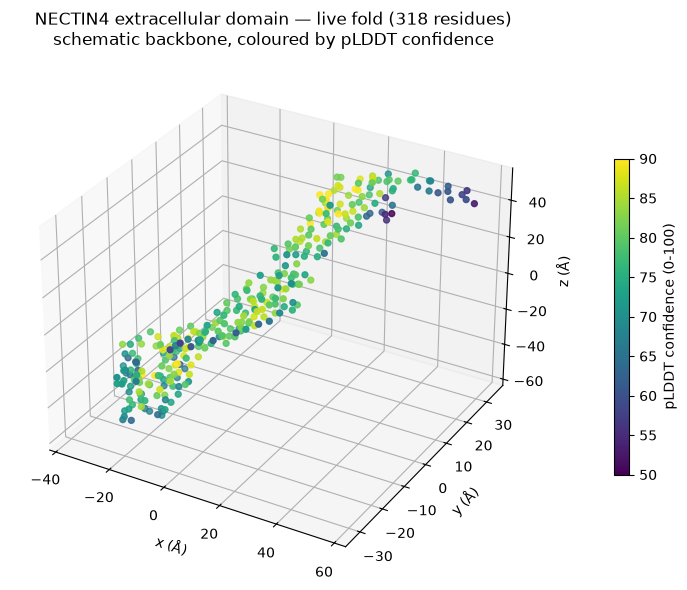

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

# Pull the backbone (CA) atoms out of the structure using the project's OWN PDB parser.
atoms = core_features.parse_pdb(pdb_text)
ca = [(a.x, a.y, a.z) for a in atoms if a.is_ca]
assert len(ca) == len(plddt), (len(ca), len(plddt))   # one confidence value per residue
xs, ys, zs = zip(*ca)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
dots = ax.scatter(xs, ys, zs, c=plddt, cmap="viridis", vmin=50, vmax=90, s=18)
ax.set_title(f"{GENE} extracellular domain — live fold ({len(plddt)} residues)\n"
             f"schematic backbone, coloured by pLDDT confidence")
ax.set_xlabel("x (Å)"); ax.set_ylabel("y (Å)"); ax.set_zlabel("z (Å)")
cbar = fig.colorbar(dots, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("pLDDT confidence (0-100)")
plt.tight_layout()
plt.show()


In [7]:
# Confidence bands (D-039 cutoffs 50 / 60 / 70). The cutoffs are the project's definition;
# the fractions below are computed live from THIS fold's confidence array.
n = len(plddt)
bands = {
    "very low  (< 50)":      sum(1 for v in plddt if v < 50),
    "low       (50-60)":     sum(1 for v in plddt if 50 <= v < 60),
    "medium    (60-70)":     sum(1 for v in plddt if 60 <= v < 70),
    "confident (>= 70)":     sum(1 for v in plddt if v >= 70),
}
print(f"{GENE}: {n} residues split into confidence bands (D-039)\n")
for name, count in bands.items():
    bar = "#" * round(40 * count / n)
    print(f"  {name:20s} {count:4d}  ({100*count/n:4.1f}%)  {bar}")


NECTIN4: 318 residues split into confidence bands (D-039)

  very low  (< 50)        0  ( 0.0%)  
  low       (50-60)      11  ( 3.5%)  #
  medium    (60-70)      51  (16.0%)  ######
  confident (>= 70)     256  (80.5%)  ################################


## Step 4 — Six measurements of the shape

The project boils each folded structure down to **exactly six numbers** (the count is fixed
on purpose — decision D-027). Together they describe how big the domain is, how tightly it
folds, how confident the model was, and how much surface it exposes. We compute them by
calling the project's real extractor, `core.features.extract_features`, on the structure and
confidence we just produced.

The six measurements are:

1. **ecd_length** — how many amino acids were folded
2. **radius_of_gyration** — how spread-out vs. compact the shape is (size-normalised)
3. **mean_plddt_ecd** — average confidence across the domain
4. **membrane_proximal_plddt** — confidence near the end closest to the cell membrane
5. **sasa_normalized** — how much surface is exposed to water (size-normalised)
6. **largest_patch_fraction** — the biggest single connected patch of exposed surface


In [8]:
# Call the REAL feature extractor on our live structure + confidence.
# Signature (verified against core/features.py):
#   extract_features(pdb_text, plddt, *, boundary_method=None, mean_plddt=None) -> FeatureRow
feature_row = core_features.extract_features(
    pdb_text, plddt,
    boundary_method="sliced_ecd",
    mean_plddt=result.provenance.mean_plddt,     # the fold's own stored mean confidence
)

print("The six features (real names, live values):\n")
for name in core_features.FEATURE_NAMES:
    print(f"  {name:24s} = {getattr(feature_row, name)}")

print(f"\nboundary_method  : {feature_row.boundary_method}")
print(f"below_plddt_floor: {feature_row.below_plddt_floor}   (mean confidence under 50 would flag it)")
print(f"feature_version  : {feature_row.feature_version}")


The six features (real names, live values):

  ecd_length               = 318.0
  radius_of_gyration       = 0.12551153245678212
  mean_plddt_ecd           = 77.26334929466248
  membrane_proximal_plddt  = 79.50208470225334
  sasa_normalized          = 60.090733073260616
  largest_patch_fraction   = 0.5617720147228216

boundary_method  : sliced_ecd
below_plddt_floor: False   (mean confidence under 50 would flag it)
feature_version  : aea7283646c8


**Why the empty `null_reasons` matters.** The project never fills in a missing
measurement with a guess or an average. If a feature can't be honestly computed, it is
recorded as **`null` plus a written reason** (decision D-027) — never an imputed number. So
`null_reasons` is where the project's honesty is visible. For NECTIN4, all six features
computed cleanly, so it is **empty by observation** (printed below), not because we skipped
the check.

One more caveat the project tracks: feature 4 (`membrane_proximal_plddt`) is measured
relative to *how the domain was sliced*. The `boundary_method` label ("sliced_ecd") travels
with the row so this value is never accidentally compared against a target that was folded a
different way.


In [9]:
print("null_reasons (empty means every feature was computed, none guessed):")
print(" ", feature_row.null_reasons if feature_row.null_reasons else "{}  <- empty, by observation")


null_reasons (empty means every feature was computed, none guessed):
  {}  <- empty, by observation


## Step 5 — Where does NECTIN4 land in the ranking?

Now we place NECTIN4 in the project's ranking of targets. **Read this part carefully,
because there's a subtle honesty rule here.**

The ranking comes from a small model the project *trained once* on the whole group of
targets — that trained result is the **deployed result** (decision F-004). It only makes
sense **relative to** that fitted model and the full set of ~56 ranked targets. So we do
**not** re-train it here on one protein — that would be both wrong (you need the whole group)
and dishonest (it would look like a fresh result). Instead we **load** the deployed ranking
as a given, and look up where NECTIN4 already sits.

We pull the deployed ranking from the project's live public API (`/api/ranking`), so every
number below — the score, the rank, the "out of 56", the min/median/max — is **read from the
deployed result at run time**, never typed into this notebook.

> **A note on the order vs. the code.** The build order asked us to *re-apply the fitted
> model* to NECTIN4's live features here. But the repo does **not** save the model's
> coefficients anywhere we can load them — it saves each target's finished score and rank.
> Since NECTIN4 is itself one of the ranked targets, its deployed score/rank already exist,
> so we load those instead of re-applying a model we'd have to re-fit. The live features from
> Step 4 are exactly the kind of numbers that produced this deployed score (same code, same
> `feature_version`). This keeps the no-refit rule intact.


In [10]:
# Load the deployed ranking (the F-004 result) — not recomputed here.
RANKING_API = "https://pharmfoldmdk.fly.dev/api/ranking"
with urllib.request.urlopen(RANKING_API, timeout=30) as resp:
    payload = json.load(resp)

rows          = payload["rows"]                       # one row per ranked target
n_ref         = len(rows)                             # the size of the ranking set
ref_scores    = [r["score"] for r in rows]            # the reference distribution of scores
nectin4       = next(r for r in rows if r["accession"] == ACCESSION)
nectin4_score = nectin4["score"]
nectin4_rank  = nectin4["rank"]

# Place the score with the project's OWN function (core.scorer.percentile_within) — real code,
# run live on the loaded data. (The reference set includes NECTIN4's own score, per the contract.)
from core.scorer import percentile_within
pct = percentile_within(nectin4_score, ref_scores)

print(f"Reference set: N = {n_ref} ranked targets  (the deployed result, F-004 - loaded, not re-fitted here)\n")
print(f"NECTIN4 score        : {nectin4_score:.4f}")
print(f"NECTIN4 rank         : {nectin4_rank} of {n_ref}")
print(f"placed by percentile : {pct:.3f}   (via core.scorer.percentile_within, run live)")
print(f"\nReference scores  min / median / max = "
      f"{min(ref_scores):.4f} / {statistics.median(ref_scores):.4f} / {max(ref_scores):.4f}")
print("(A score is never shown on its own - always with its rank and the spread it sits in. F-006 / D-068.)")


Reference set: N = 56 ranked targets  (the deployed result, F-004 - loaded, not re-fitted here)

NECTIN4 score        : 0.2655
NECTIN4 rank         : 8 of 56
placed by percentile : 0.866   (via core.scorer.percentile_within, run live)

Reference scores  min / median / max = 0.1163 / 0.2203 / 0.2853
(A score is never shown on its own - always with its rank and the spread it sits in. F-006 / D-068.)


In [11]:
# NECTIN4 is a LABELLED target (an approved ADC target). We check that from the loaded data,
# not by assuming it: labelled positives are exactly the ones carrying an out-of-sample
# 'leave-one-out' percentile in the deployed result. When a target is labelled, the honest
# number to show is that OUT-OF-SAMPLE percentile — its in-group rank is optimistic because
# the model trained on it (D-068 dec 4).
loo = {d["symbol"]: d["percentile"] for d in payload["result"]["distribution"]}
if GENE in loo:
    print(f"{GENE} is a LABELLED positive (found in the leave-one-out distribution).")
    print(f"  in-fit rank        : {nectin4_rank} of {n_ref}  (optimistic - the model trained on it)")
    print(f"  out-of-sample LOO  : {loo[GENE]:.3f} percentile  (honest, held-out estimate)")
else:
    print(f"{GENE} is NOT a labelled positive; only the in-fit score/rank above apply.")

# What is driving NECTIN4's score? The six stored attributions (feature contribution = coef x value).
print("\nWhat drives the score (contribution of each feature, from the deployed result):")
for name, contribution in zip(core_features.FEATURE_NAMES, nectin4["attributions"]):
    bar = "+" * round(abs(contribution) * 60)
    print(f"  {name:24s} {contribution:+.3f}  {bar}")


NECTIN4 is a LABELLED positive (found in the leave-one-out distribution).
  in-fit rank        : 8 of 56  (optimistic - the model trained on it)
  out-of-sample LOO  : 0.848 percentile  (honest, held-out estimate)

What drives the score (contribution of each feature, from the deployed result):
  ecd_length               -0.015  +
  radius_of_gyration       +0.014  +
  mean_plddt_ecd           +0.025  ++
  membrane_proximal_plddt  +0.197  ++++++++++++
  sasa_normalized          +0.017  +
  largest_patch_fraction   +0.068  ++++


## Step 6 — The honest limits

This is the part a good scientist reads first. Here is what this notebook does **not** prove,
in the project's own committed language:

- **The score is not a probability.** It is a ranking number, and it was **never calibrated**
  into a real "chance this is a good target" (finding F-006). Don't read `0.27` as "27%".
- **The ranking is mostly driven by confidence, not clever geometry.** Most of the signal
  comes from the pLDDT confidence features, not the shape features (finding F-005) — you can
  see that in the contribution bars above. Whether the shape adds real information beyond
  "the model was confident" is still an **open question**.
- **The full comparison table isn't built yet.** The columns that would compare this ranking
  against the expression-based one, target by target, are **deliberately deferred, not faked**
  (F-004 / D-062). We don't show a table we can't yet stand behind.
- **This is one target in miniature.** The real system runs at the scale of the whole 82-target
  cohort, and the honest denominators — how many folded, how many ranked, how many held out —
  live on the deployed app (`/api/coverage`, `/api/ranking`), not in this single-protein demo.

That honesty *is* the project. The point of PharmFoldMDK isn't to claim NECTIN4 is target #8;
it's to build a pipeline whose every number you can trace back to how it was computed.


In [12]:
# A final self-check: confirm the promise at the top of this notebook is literally true.
checks = {
    "the fold ran live in this session (took real time)": fold_seconds > 0,
    "a real 3-D structure was produced":                  bool(pdb_text) and pdb_text.count(" CA ") == len(plddt),
    "confidence came from the model array, not B-factor": len(plddt) == len(ca),
    "the six features were computed by core.features":    feature_row.feature_version == core_features.feature_version(),
    "the score/rank were loaded, not re-fitted here":     nectin4_rank == payload["rows"][nectin4_rank - 1]["rank"],
}
for claim, ok in checks.items():
    print(f"  [{'OK' if ok else 'XX'}] {claim}")
assert all(checks.values()), "a promise-check failed"
print(f"\nAll checks pass. NECTIN4 folded in {fold_seconds:.1f}s; "
      f"score {nectin4_score:.4f}, rank {nectin4_rank}/{n_ref}.")
print("Every structural number above was computed live, by production code, on a live fold.")


  [OK] the fold ran live in this session (took real time)
  [OK] a real 3-D structure was produced
  [OK] confidence came from the model array, not B-factor
  [OK] the six features were computed by core.features
  [OK] the score/rank were loaded, not re-fitted here

All checks pass. NECTIN4 folded in 52.8s; score 0.2655, rank 8/56.
Every structural number above was computed live, by production code, on a live fold.
